# UT4 - Practica 7: Analisis de Objetos y Contornos

**Objetivo:** Dominar la deteccion de formas, calculo de metricas y filtrado de objetos industriales.

---

### PASO 0: Generador de Material (Ejecutar una vez)
Ejecuta este codigo para crear la imagen `practica_contornos.png`.

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Crear lienzo negro
img = np.zeros((600, 800, 3), dtype=np.uint8)

# Dibujar formas (Simulando piezas)
cv2.rectangle(img, (50, 50), (150, 150), (255, 255, 255), -1) # Cuadrado
cv2.circle(img, (300, 100), 50, (255, 255, 255), -1)          # Circulo
cv2.circle(img, (300, 100), 20, (0, 0, 0), -1)                # Agujero en circulo (Arandela)
pts = np.array([[500, 50], [450, 150], [550, 150]], np.int32)
cv2.fillPoly(img, [pts], (255, 255, 255))                     # Triangulo
cv2.rectangle(img, (600, 50), (750, 100), (255, 255, 255), -1)# Rectangulo girado

# Rotacion del rectangulo
center = (675, 75); M = cv2.getRotationMatrix2D(center, 45, 1.0)
img = cv2.warpAffine(img, M, (800, 600))

# Anadir "Ruido" (motas de polvo blancas)
for _ in range(50):
    x, y = np.random.randint(0, 800), np.random.randint(0, 600)
    cv2.circle(img, (x, y), 2, (255, 255, 255), -1)

cv2.imwrite('practica_contornos.png', img)
print("Imagen generada con exito.")

Imagen generada con exito.


---

## BLOQUE 1: Ejercicios Guiados
Lee el codigo, ejecutalo y asegurate de entender que hace cada linea.

### Ejercicio 1: "Hola Mundo" en Contornos
**Objetivo:** Cargar imagen, binarizar y encontrar todos los contornos externos.

He encontrado 53 contornos (incluyendo ruido).


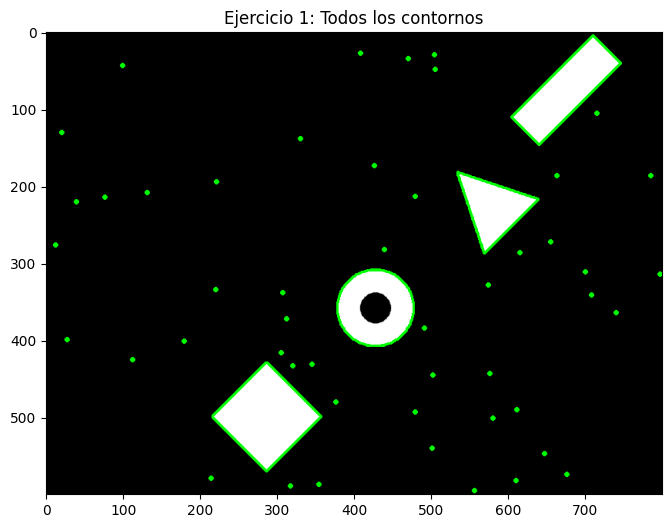

In [44]:
image = cv2.imread('practica_contornos.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 2. Binarizacion (Fundamental: Blanco=Objeto, Negro=Fondo)
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# 3. Encontrar contornos
contours, hierarchy = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

print(f"He encontrado {len(contours)} contornos (incluyendo ruido).")

# 4. Dibujar
output = image.copy()
cv2.drawContours(output, contours, -1, (0, 255, 0), 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 1: Todos los contornos")
plt.show()

### Ejercicio 2: Filtro de Ruido por Area
**Objetivo:** Eliminar las pequenas motas de polvo (ruido) que no son piezas reales.

Piezas validas despues de filtrar: 4


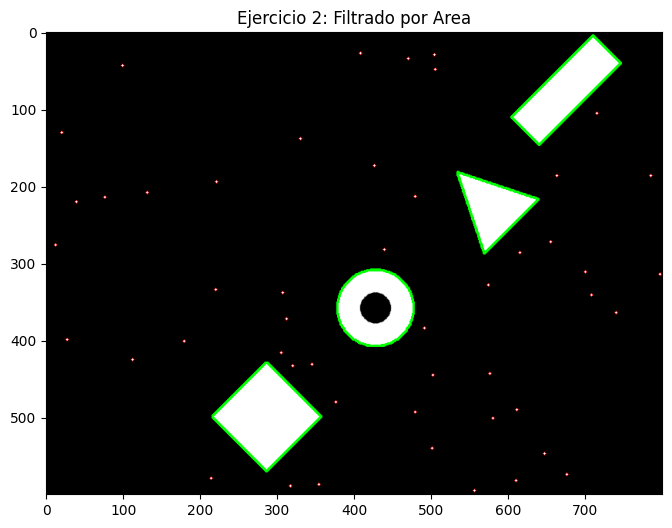

In [45]:
output = image.copy()
min_area = 100  # Umbral arbitrario para filtrar ruido

filtered_contours = []

for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > min_area:
        filtered_contours.append(cnt)
        cv2.drawContours(output, [cnt], -1, (0, 255, 0), 2)
    else:
        cv2.drawContours(output, [cnt], -1, (0, 0, 255), 1)

print(f"Piezas validas despues de filtrar: {len(filtered_contours)}")

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 2: Filtrado por Area")
plt.show()

### Ejercicio 3: Bounding Box (Etiquetado)
**Objetivo:** Encerrar cada objeto en una caja y ponerle una etiqueta numerica.

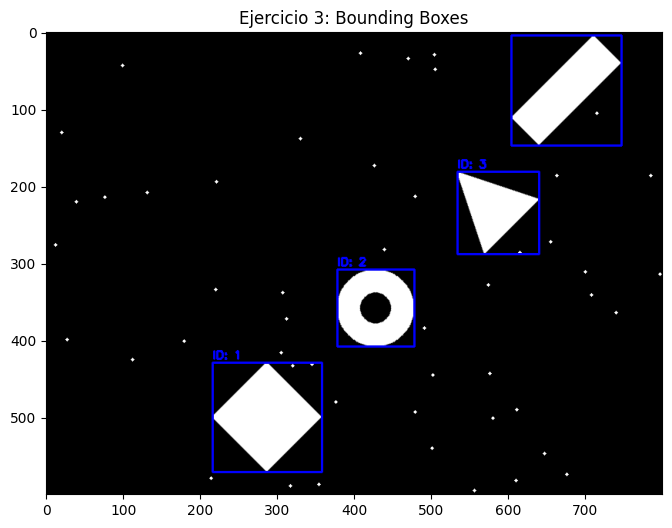

In [46]:
output = image.copy()

for i, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(output, f"ID: {i+1}", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 3: Bounding Boxes")
plt.show()

---

## BLOQUE 2: Semi-Guiados
Completa los huecos marcados con `___`.

### Ejercicio 4: Centroides y Momentos
**Objetivo:** Calcular el centro exacto de cada pieza.
**Pista:** El centroide se calcula con los momentos $M_{10}$ (para X) y $M_{01}$ (para Y) divididos por el area.

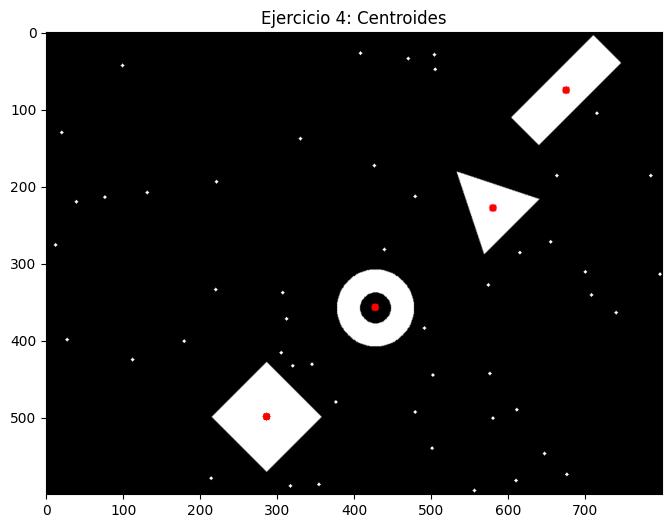

In [47]:
output = image.copy()

for cnt in filtered_contours:
    # 1. Calcular momentos
    M = cv2.moments(cnt)
    
    if M["m00"] != 0:
        # 2. Calcular coordenadas del centro (COMPLETAR LA FORMULA)
        # Tienes que dividir el momento espacial entre el area (m00)
        cX = int( M["m10"] / M["m00"] )
        cY = int( M["m01"] / M["m00"] )
        
        # 3. Dibujar un punto en el centro
        cv2.circle(output, (cX, cY), 5, (0, 0, 255), -1)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 4: Centroides")
plt.show()

### Ejercicio 5: Detectando Agujeros (Jerarquia)
**Objetivo:** Detectar que piezas tienen agujeros (como arandelas).
**Teoria:** Usar `RETR_TREE`. La jerarquia es `[Siguiente, Anterior, Hijo, Padre]`.

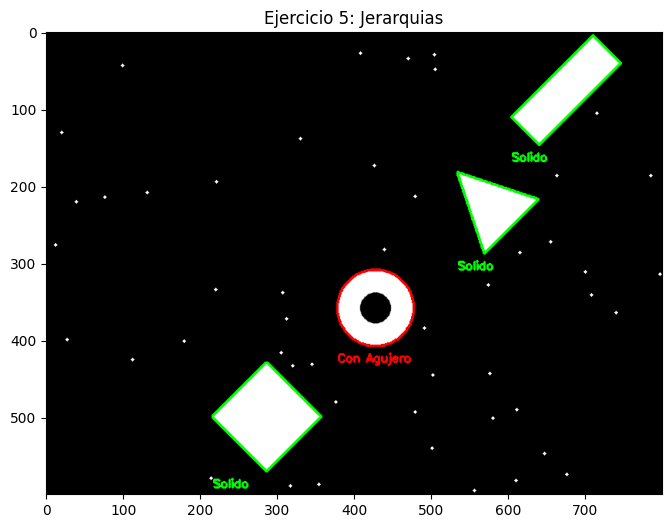

In [48]:
# Cambiamos a RETR_TREE
contours_tree, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

output = image.copy()
hierarchy = hierarchy[0] 

for i, (cnt, hier) in enumerate(zip(contours_tree, hierarchy)):
    area = cv2.contourArea(cnt)
    if area < 100: continue # Filtro ruido

    # 1. Extrae el indice del HIJO de la jerarquia (Recuerda: [Next, Prev, Child, Parent])
    child_index = hier[2]
    
    # 2. Escribe la logica: Si el indice es distinto de -1, es "Con Agujero" (Rojo). Si no, "Solido" (Verde).
    if child_index != -1:
        color = (0, 0, 255)
        etiqueta = "Con Agujero"
    else:
        color = (0, 255, 0)
        etiqueta = "Solido"
        
        
    # Dibujar solo si es un contorno externo (Padre == -1)
    if hier[3] == -1:
        cv2.drawContours(output, [cnt], -1, color, 2)
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.putText(output, etiqueta, (x, y+h+20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 5: Jerarquias")
plt.show()

### Ejercicio 6: Clasificador de Formas
**Objetivo:** Contar vertices para saber que forma es.

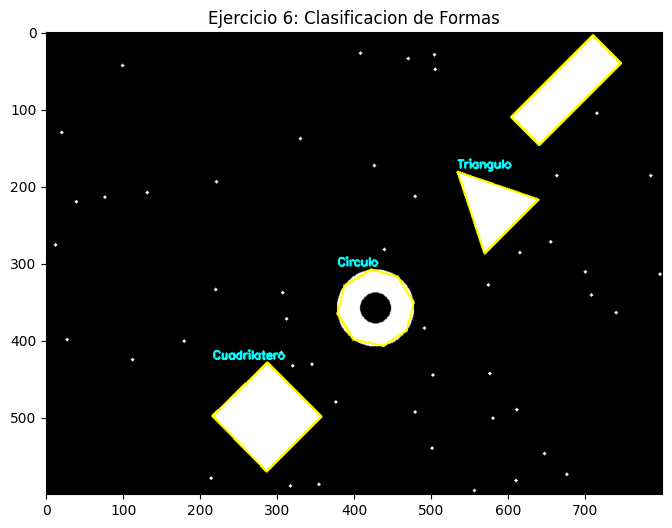

In [49]:
output = image.copy()

for cnt in filtered_contours:
    perimeter = cv2.arcLength(cnt, True)
    
    # 1. Calcula epsilon (Factor de precision). Suele ser entre 0.02 y 0.04 veces el perimetro.
    epsilon = 0.03 * perimeter
    
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    vertices = len(approx)
    
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Clasifica segun el numero de vertices:
    # 3 -> Triangulo
    # 4 -> Cuadrilatero
    # >6 -> Circulo
    if vertices == 3:
        shape_name = "Triangulo"
    elif vertices == 4:
        shape_name = "Cuadrilatero"
    elif vertices > 6:
        shape_name = "Circulo"
    else:
        shape_name = "Otro"

    cv2.putText(output, shape_name, (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 0), 2)
    cv2.drawContours(output, [approx], -1, (0, 255, 255), 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 6: Clasificacion de Formas")
plt.show()

---

## BLOQUE 3: Retos
A partir de aqui, debes escribir tu el codigo desde cero.

### Ejercicio 7: La Caja Rotada
Usa `cv2.minAreaRect`, `cv2.boxPoints` y `np.int64` para dibujar el rectangulo ajustado a la rotacion.

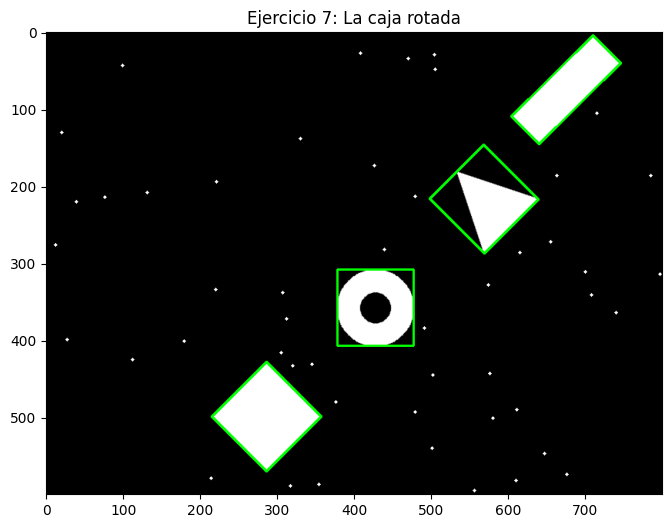

In [50]:
output_rot = image.copy()

for i, cnt in enumerate(filtered_contours):
    rect = cv2.minAreaRect(cnt)
    box = cv2.boxPoints(rect)
    box = np.int64(box)
    cv2.drawContours(output_rot, [box], -1, (0, 255, 0), 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output_rot, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 7: La caja rotada")
plt.show()

### Ejercicio 8: Recortar Objetos (ROI)
Recorta cada pieza usando Slicing de Numpy `img[y:y+h, x:x+w]` y muestralas.

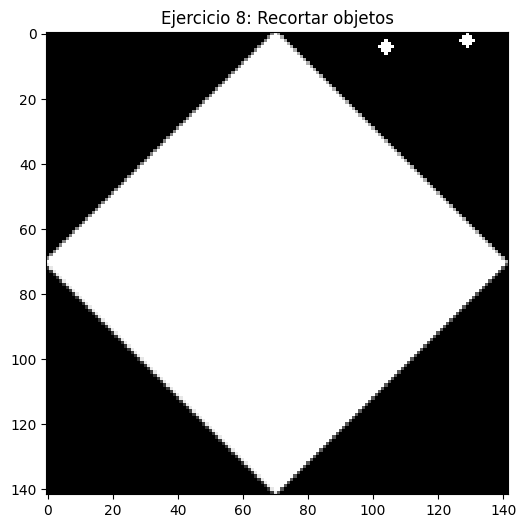

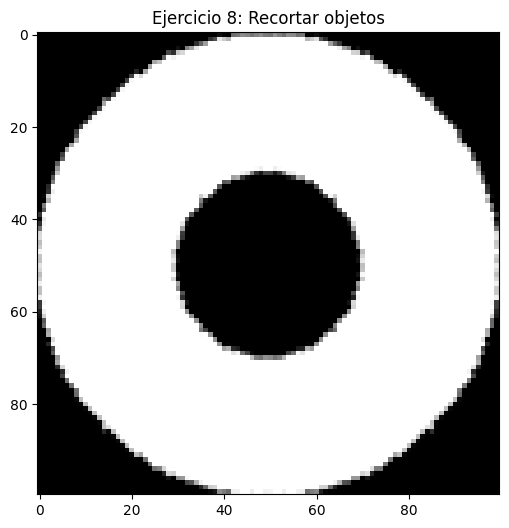

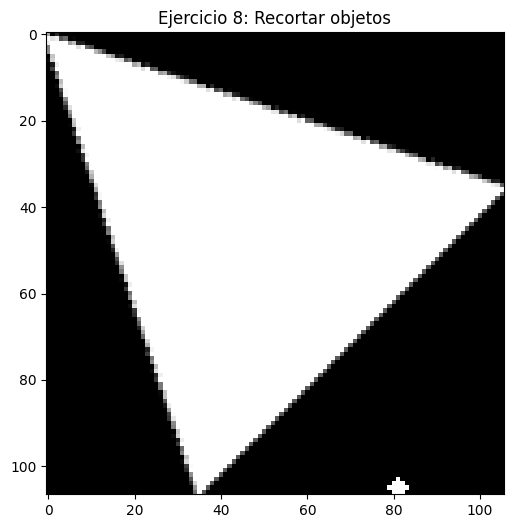

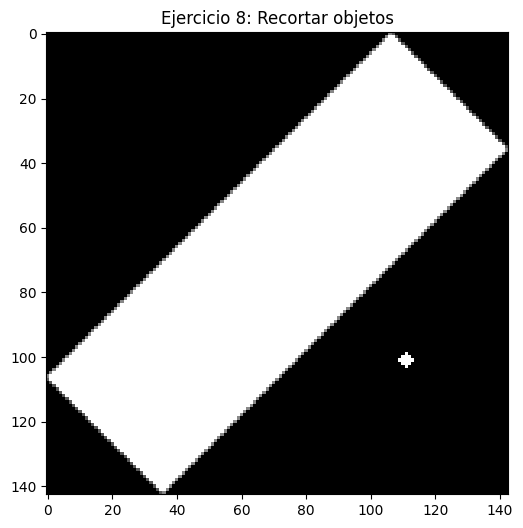

In [51]:
imagenes = []

for i, cnt in enumerate(filtered_contours):
    x, y, w, h = cv2.boundingRect(cnt)
    imagen = img[y:y+h, x:x+w]
    imagenes.append(imagen)

for imagen in imagenes:
    plt.figure(figsize=(10,6))
    plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
    plt.title("Ejercicio 8: Recortar objetos")
    plt.show()

### Ejercicio 9: Ordenar de Izquierda a Derecha
Ordena los contornos segun su coordenada X antes de etiquetarlos.

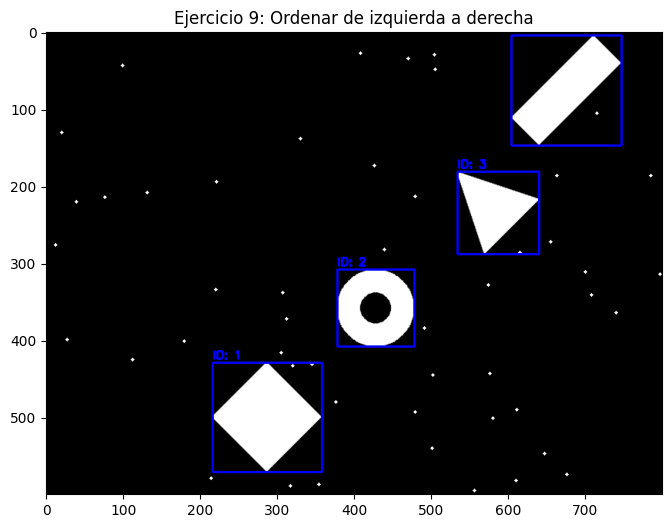

In [52]:
contornos_sorted = sorted(filtered_contours, key= lambda l: cv2.boundingRect(l)[0])
output_sorted = image.copy()
for i, cnt in enumerate(contornos_sorted):
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output_sorted, (x, y), (x + w, y + h), (255, 0, 0), 2)
    cv2.putText(output_sorted, f"ID: {i+1}", (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output_sorted, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 9: Ordenar de izquierda a derecha")
plt.show()

### Ejercicio 10: Control de Calidad
Pinta en VERDE solo los Circulos con Agujero (Arandelas). Todo lo demas en ROJO.

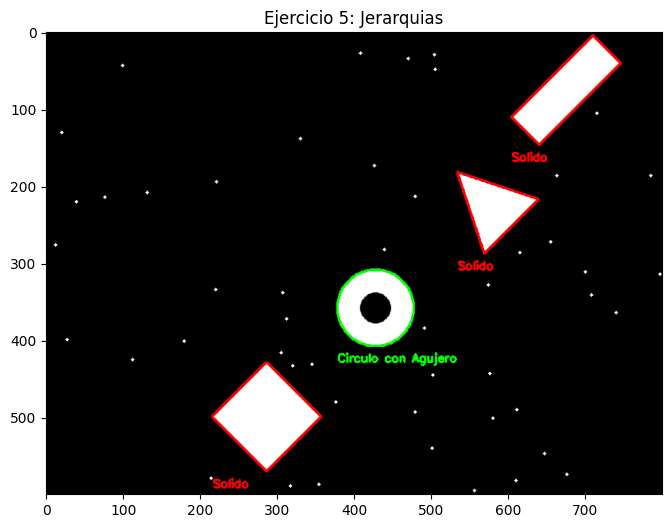

In [54]:
image = cv2.imread('practica_contornos.png')
contours_tree, hierarchy = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

output_control = image.copy()
hierarchy = hierarchy[0]
for i, (cnt, hier) in enumerate(zip(contours_tree, hierarchy)):
    area = cv2.contourArea(cnt)
    if area < 100: continue # Filtro ruido

    child_index = hier[2]
    
    perimeter = cv2.arcLength(cnt, True)
    
    # Calcula epsilon (Factor de precision). Suele ser entre 0.02 y 0.04 veces el perimetro.
    epsilon = 0.03 * perimeter
    
    approx = cv2.approxPolyDP(cnt, epsilon, True)
    vertices = len(approx)
    
    x, y, w, h = cv2.boundingRect(cnt)
    
    # Clasifica segun el numero de vertices:
    # 3 -> Triangulo
    # 4 -> Cuadrilatero
    # >6 -> Circulo
    if vertices == 3:
        shape_name = "Triangulo"
    elif vertices == 4:
        shape_name = "Cuadrilatero"
    elif vertices > 6:
        shape_name = "Circulo"
    else:
        shape_name = "Otro"


    if child_index != -1 and shape_name == "Circulo":
        color = (0, 255, 0)
        etiqueta = "Circulo con Agujero"
    else:
        color = (0, 0, 255)
        etiqueta = "Solido"
        
    if hier[3] == -1:
        cv2.drawContours(output_control, [cnt], -1, color, 2)
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.putText(output_control, etiqueta, (x, y+h+20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

plt.figure(figsize=(10,6))
plt.imshow(cv2.cvtColor(output_control, cv2.COLOR_BGR2RGB))
plt.title("Ejercicio 5: Jerarquias")
plt.show()